In [1]:
# Uncomment these in a fresh notebook environment.
#%pip install -r ../requirements.txt
#%pip install -e ..

In [2]:
%reload_ext autoreload
%autoreload 2

from marl_tsc.network_types import CityNetwork, GridNetwork
from marl_tsc.simulation_generator import SimulationGenerator
from marl_tsc.training import train_ppo, evaluate_policy, export_policy_replay, plot_evaluation_results, plot_training_histories
from marl_tsc.mappo import train_mappo
from marl_tsc.baselines import random_actions, fixed_time_actions
from pathlib import Path
import matplotlib.pyplot as plt

GREEN_PHASE_COUNT = None  # Let SUMO/network discovery choose the phase count.
NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if (NOTEBOOK_DIR / "main_flow.ipynb").exists() else NOTEBOOK_DIR
OUTPUT_DIR = PROJECT_ROOT / "outputs"

## Generate the SUMO simulation files

This default setup is a small `4x4` grid with four traffic-light agents. Change `network` to use a UK city network instead.


In [ ]:
EPISODE_STEPS = 600
SECONDS_PER_ACTION = 5
SIMULATION_DURATION = EPISODE_STEPS * SECONDS_PER_ACTION

# Keep vehicles entering slightly longer than the episode runs.
TRAFFIC_SPAWN_DURATION = int(SIMULATION_DURATION * 1.20)

EVALUATION_EPISODES = 3
TOTAL_TIMESTEPS = 120_000
MIN_GREEN_SECONDS = 10
SWITCH_PENALTY = 0.1

# network = GridNetwork()
network = CityNetwork(city_name="London, UK", radius=350)

generator = SimulationGenerator(
    output_dir=OUTPUT_DIR,
    network=network,
    trip_begin=0,
    trip_end=TRAFFIC_SPAWN_DURATION,
    trip_period=3,
    seed=42,
)

paths = generator.generate_all()
traffic_light_ids = list(paths.traffic_light_ids)
print(f"Generated SUMO config: {paths.config_file}")
print(f"Simulation horizon: {SIMULATION_DURATION}s")
print(f"Traffic spawn duration: {TRAFFIC_SPAWN_DURATION}s")
print("Traffic-light agent count:", len(traffic_light_ids))

Generated SUMO config: C:\Code\marl-tsc\outputs\config.sumocfg
Simulation horizon: 3000s
Traffic spawn duration: 3600s
Traffic-light agent count: 10


## Train

PPO uses parameter sharing through the PettingZoo/SuperSuit/SB3 wrapper. MAPPO adds a centralized critic and a shared decentralized actor.

### PPO

[PPO] Step 6000 | Network Episode Return: -504.72
[PPO] Step 12000 | Network Episode Return: -481.33
[PPO] Step 18000 | Network Episode Return: -460.10


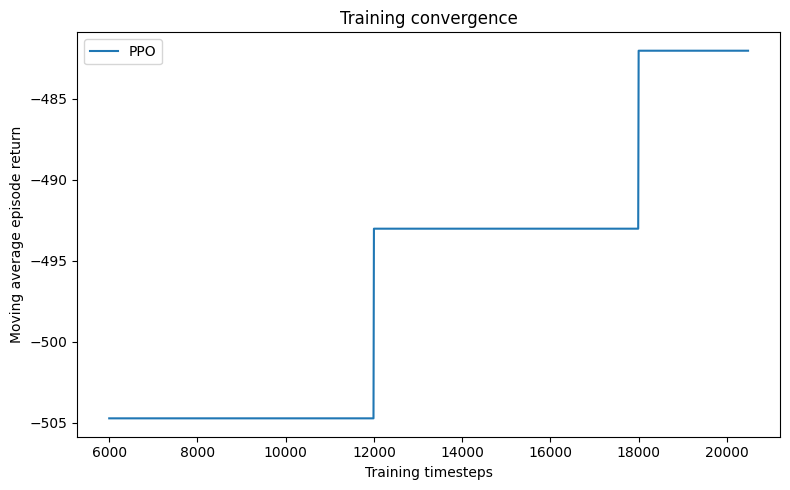

In [4]:
ppo_model, ppo_history, ppo_model_path = train_ppo(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    output_dir=OUTPUT_DIR,
    total_timesteps=TOTAL_TIMESTEPS,
    max_steps=EPISODE_STEPS,
    seed=42,
    env_kwargs={
        "green_phase_count": GREEN_PHASE_COUNT,
        "min_green_seconds": MIN_GREEN_SECONDS,
        "seconds_per_action": SECONDS_PER_ACTION,
        "switch_penalty": SWITCH_PENALTY,
    },
)

fig, ax = plot_training_histories(ppo_history)
plt.show()

### MAPPO

[MAPPO] Episode 1 | Return: -485.05 | Total Steps: 600
[MAPPO] Episode 2 | Return: -482.33 | Total Steps: 1200
[MAPPO] Episode 3 | Return: -457.74 | Total Steps: 1800
[MAPPO] Episode 4 | Return: -487.62 | Total Steps: 2400
[MAPPO] Episode 5 | Return: -485.73 | Total Steps: 3000
[MAPPO] Episode 6 | Return: -461.20 | Total Steps: 3600
[MAPPO] Episode 7 | Return: -479.06 | Total Steps: 4200
[MAPPO] Episode 8 | Return: -519.82 | Total Steps: 4800
[MAPPO] Episode 9 | Return: -517.22 | Total Steps: 5400
[MAPPO] Episode 10 | Return: -462.11 | Total Steps: 6000
[MAPPO] Episode 11 | Return: -477.37 | Total Steps: 6600
[MAPPO] Episode 12 | Return: -491.59 | Total Steps: 7200
[MAPPO] Episode 13 | Return: -493.95 | Total Steps: 7800
[MAPPO] Episode 14 | Return: -466.58 | Total Steps: 8400
[MAPPO] Episode 15 | Return: -486.62 | Total Steps: 9000
[MAPPO] Episode 16 | Return: -483.54 | Total Steps: 9600
[MAPPO] Episode 17 | Return: -482.94 | Total Steps: 10200
[MAPPO] Episode 18 | Return: -522.72 | T

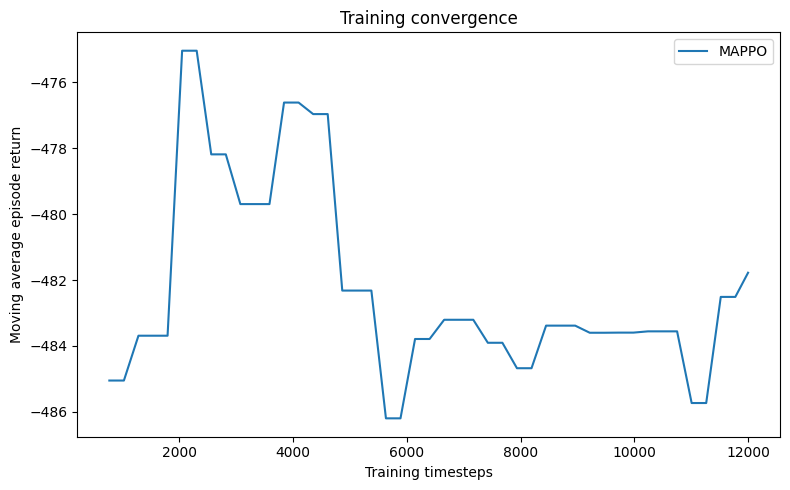

In [5]:
mappo_model, mappo_history, mappo_model_path = train_mappo(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    output_dir=OUTPUT_DIR,
    total_timesteps=TOTAL_TIMESTEPS,
    rollout_steps=256,
    max_steps=EPISODE_STEPS,
    seed=42,
    env_kwargs={
        "green_phase_count": GREEN_PHASE_COUNT,
        "min_green_seconds": MIN_GREEN_SECONDS,
        "seconds_per_action": SECONDS_PER_ACTION,
        "switch_penalty": SWITCH_PENALTY,
    },
)

fig, ax = plot_training_histories(mappo_history)
plt.show()

## Export SUMO GUI replay

This writes a replay of a policy on a network that can be opened directly from the SUMO GUI.

In [6]:
replay_config = export_policy_replay(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    policy=mappo_model,
    output_dir=OUTPUT_DIR / "replays" / "mappo",
    max_steps=EPISODE_STEPS,
    seed=42,
    env_kwargs={
        "green_phase_count": GREEN_PHASE_COUNT,
        "min_green_seconds": MIN_GREEN_SECONDS,
        "seconds_per_action": SECONDS_PER_ACTION,
        "switch_penalty": SWITCH_PENALTY,
    },
)

print(f"Open this file in SUMO GUI: {replay_config}")

Open this file in SUMO GUI: C:\Code\marl-tsc\outputs\replays\mappo\replay.sumocfg


## Evaluate policies

The final comparison uses the same evaluation seeds for every policy.


In [7]:
def get_evaluation_results(policy):
    return evaluate_policy(
        config_file=paths.config_file,
        traffic_light_ids=traffic_light_ids,
        policy=policy,
        episodes=EVALUATION_EPISODES,
        max_steps=EPISODE_STEPS,
        seed=42,
        env_kwargs={
            "green_phase_count": GREEN_PHASE_COUNT,
            "min_green_seconds": MIN_GREEN_SECONDS,
            "seconds_per_action": SECONDS_PER_ACTION,
            "switch_penalty": SWITCH_PENALTY,
            "global_metric_interval": 10,
        },
    )

In [8]:
policies = {
    "Random": random_actions,
    "Fixed-Time": fixed_time_actions,
    "Shared PPO": ppo_model,
    "MAPPO": mappo_model,
}

policy_results = {}

for name, policy in policies.items():
    print(f"Evaluating {name} model")
    policy_result = get_evaluation_results(policy)
    policy_results[name] = policy_result

Evaluating Random model
Finished Evaluation Episode 1/3 - Total Reward: -4694.07
Finished Evaluation Episode 2/3 - Total Reward: -4770.41
Finished Evaluation Episode 3/3 - Total Reward: -4377.87
Evaluating Fixed-Time model
Finished Evaluation Episode 1/3 - Total Reward: -5063.91
Finished Evaluation Episode 2/3 - Total Reward: -5224.68
Finished Evaluation Episode 3/3 - Total Reward: -4815.61
Evaluating Shared PPO model
Finished Evaluation Episode 1/3 - Total Reward: -5613.24
Finished Evaluation Episode 2/3 - Total Reward: -5903.55
Finished Evaluation Episode 3/3 - Total Reward: -5831.35
Evaluating MAPPO model
Finished Evaluation Episode 1/3 - Total Reward: -6321.41
Finished Evaluation Episode 2/3 - Total Reward: -6352.89
Finished Evaluation Episode 3/3 - Total Reward: -6230.47


In [9]:
for name, result in policy_results.items():
    print(
        f"{name:10} "
        f"reward={result['mean_total_reward']:.1f}  "
        f"queue={result['mean_local_queue']:.3f}  "
        f"wait={result['mean_waiting_time']:.2f}  "
        f"max_wait={result['mean_max_waiting_time']:.2f}"
    )

Random     reward=-4614.1  queue=0.744  wait=101.20  max_wait=813.00
Fixed-Time reward=-5034.7  queue=0.828  wait=106.98  max_wait=1224.33
Shared PPO reward=-5782.7  queue=0.952  wait=121.89  max_wait=1076.67
MAPPO      reward=-6301.6  queue=1.037  wait=122.49  max_wait=1254.00


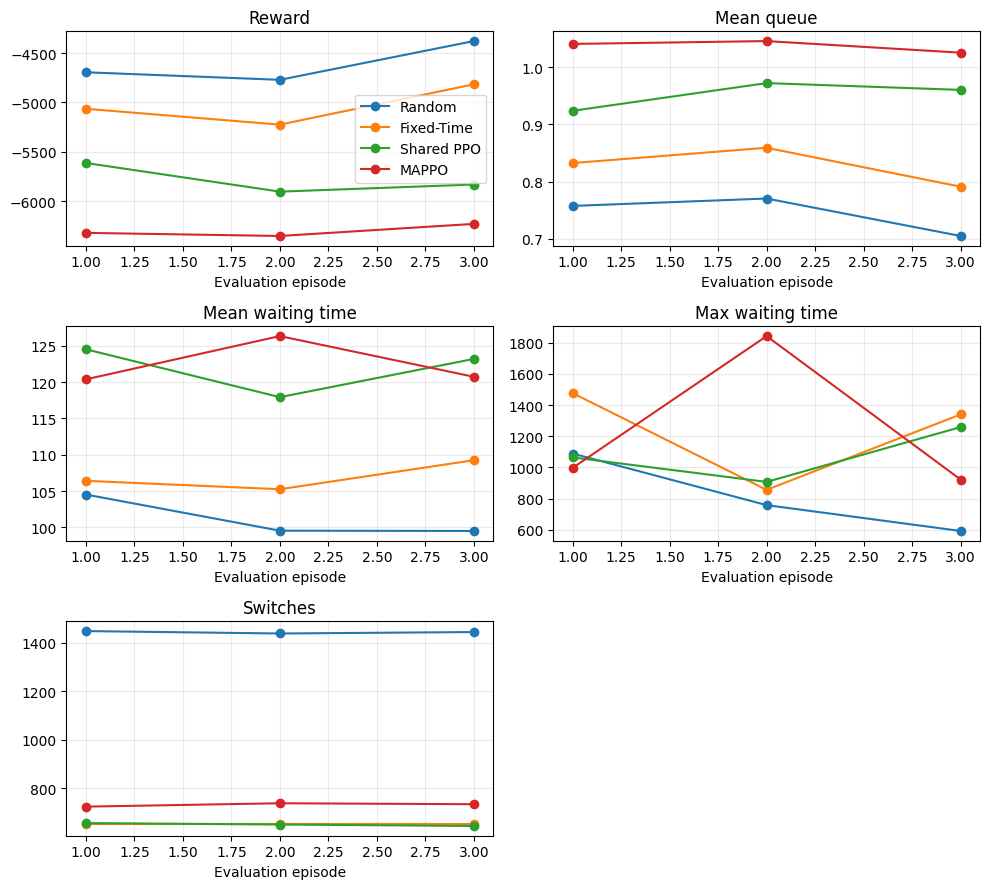

In [10]:
fig, axes = plot_evaluation_results(policy_results)
plt.show()